Sample:    155 pts, T = [-14.6, 22.0] °C
No sample: 373 pts, T = [-13.9, 24.8] °C


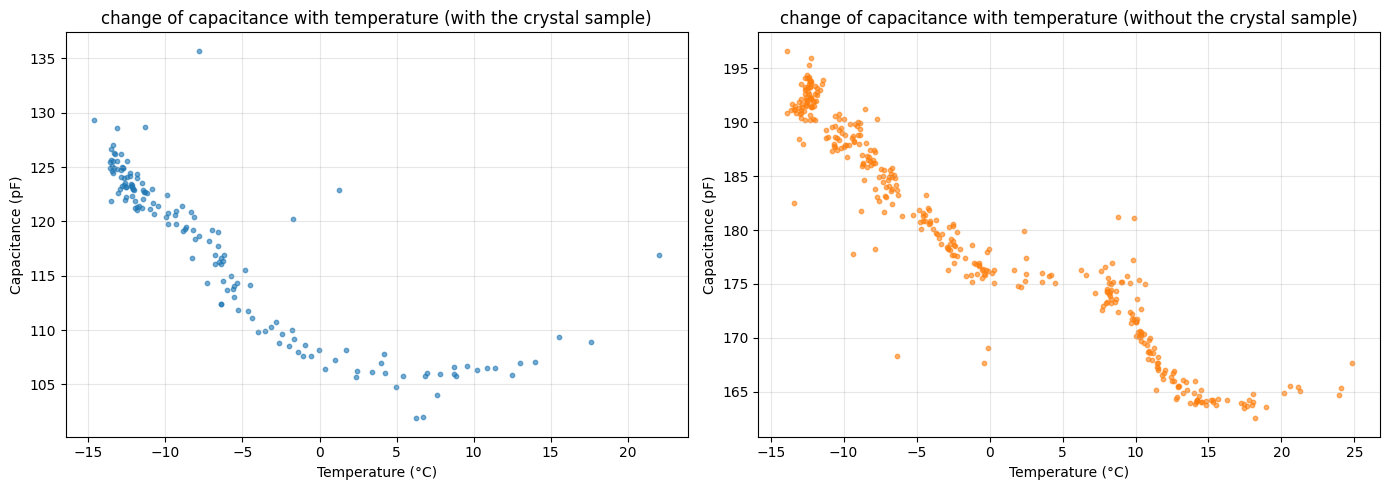

In [335]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load both datasets
df_sample = pd.read_csv('final_data/sample_capacitances.csv')
df_nosample = pd.read_csv('final_data/no_sample_capacitances.csv')

# Convert to pF
df_sample['capacitance_pF'] = df_sample['capacitance_value'] * 1e12
df_nosample['capacitance_pF'] = df_nosample['capacitance_value'] * 1e12

# Reliable temperature ranges
T_MIN_SAMPLE, T_MAX = -15 , 25
T_MIN_NOSAMPLE = T_MIN_SAMPLE

df_s = df_sample[(df_sample['temperature_C'] >= T_MIN_SAMPLE) & (df_sample['temperature_C'] <= T_MAX)].copy()
df_n = df_nosample[(df_nosample['temperature_C'] >= T_MIN_NOSAMPLE) & (df_nosample['temperature_C'] <= T_MAX)].copy()

# Remove capacitance outliers (> 3 sigma from rolling median)
for label, d in [('sample', df_s), ('no_sample', df_n)]:
    med = d['capacitance_pF'].median()
    std = d['capacitance_pF'].std()
    mask = (d['capacitance_pF'] > med - 3*std) & (d['capacitance_pF'] < med + 3*std)
    if label == 'sample':
        df_s = d[mask].copy()
    else:
        df_n = d[mask].copy()

print(f"Sample:    {len(df_s)} pts, T = [{df_s['temperature_C'].min():.1f}, {df_s['temperature_C'].max():.1f}] °C")
print(f"No sample: {len(df_n)} pts, T = [{df_n['temperature_C'].min():.1f}, {df_n['temperature_C'].max():.1f}] °C")

# Plot both datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_s['temperature_C'], df_s['capacitance_pF'], s=10, alpha=0.6, color='tab:blue')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Capacitance (pF)')
ax1.set_title('change of capacitance with temperature (with the crystal sample)')
ax1.grid(True, alpha=0.3)

ax2.scatter(df_n['temperature_C'], df_n['capacitance_pF'], s=10, alpha=0.6, color='tab:orange')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Capacitance (pF)')
ax2.set_title('change of capacitance with temperature (without the crystal sample)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With sample:    dC/dT = -0.785063 ± 0.039382 pF/°C, R² = 0.7220
Without sample: dC/dT = -0.886911 ± 0.014658 pF/°C, R² = 0.9080


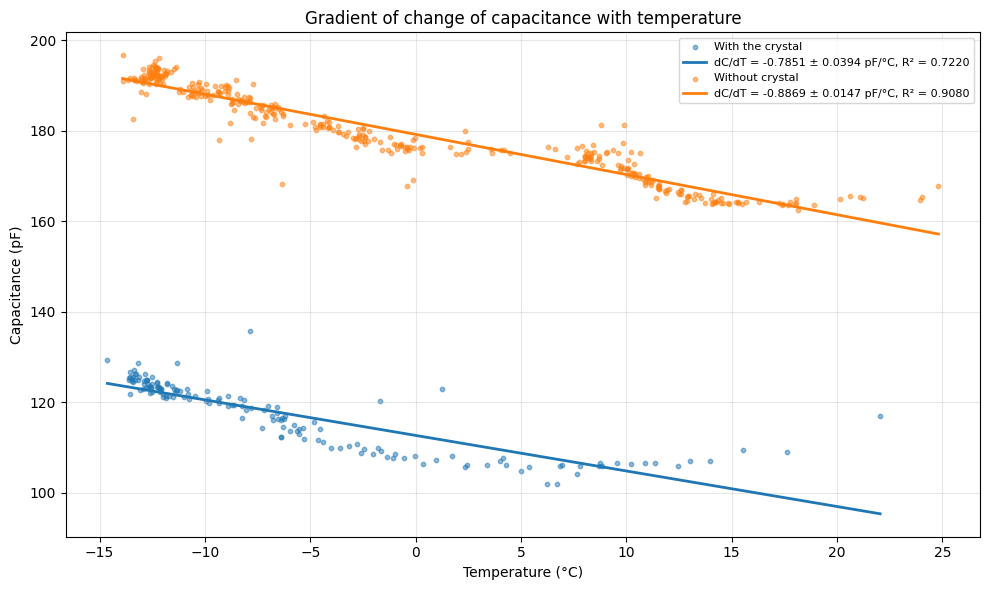

In [336]:
# Linear fit: capacitance_pF = m * temperature_C + b
m_s, b_s = np.polyfit(df_s['temperature_C'], df_s['capacitance_pF'], 1)
m_n, b_n = np.polyfit(df_n['temperature_C'], df_n['capacitance_pF'], 1)

# Standard errors and correlations
from scipy import stats
res_s = stats.linregress(df_s['temperature_C'], df_s['capacitance_pF'])
res_n = stats.linregress(df_n['temperature_C'], df_n['capacitance_pF'])
se_s = res_s.stderr
se_n = res_n.stderr
r2_s = res_s.rvalue**2
r2_n = res_n.rvalue**2

print(f"With sample:    dC/dT = {m_s:.6f} ± {se_s:.6f} pF/°C, R² = {r2_s:.4f}")
print(f"Without sample: dC/dT = {m_n:.6f} ± {se_n:.6f} pF/°C, R² = {r2_n:.4f}")

# Plot fits
t_s_fit = np.linspace(df_s['temperature_C'].min(), df_s['temperature_C'].max(), 200)
t_n_fit = np.linspace(df_n['temperature_C'].min(), df_n['temperature_C'].max(), 200)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_s['temperature_C'], df_s['capacitance_pF'], s=10, alpha=0.5, label='With the crystal', color='tab:blue')
ax.plot(t_s_fit, m_s * t_s_fit + b_s, color='tab:blue', linewidth=2,
        label=f'dC/dT = {m_s:.4f} ± {se_s:.4f} pF/°C, R² = {r2_s:.4f}')

ax.scatter(df_n['temperature_C'], df_n['capacitance_pF'], s=10, alpha=0.5, label='Without crystal', color='tab:orange')
ax.plot(t_n_fit, m_n * t_n_fit + b_n, color='tab:orange', linewidth=2,
        label=f'dC/dT = {m_n:.4f} ± {se_n:.4f} pF/°C, R² = {r2_n:.4f}')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Capacitance (pF)')
ax.set_title('Gradient of change of capacitance with temperature')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [337]:
# Reduced chi-squared for the linear fits
# Using independent noise measurements as uncertainty
sigma_s_noise = 0.7820  # pF, from sample noise runs
sigma_n_noise = 2.4280  # pF, from no-sample noise runs
print(f"Independent noise σ (sample)    = {sigma_s_noise:.4f} pF")
print(f"Independent noise σ (no sample) = {sigma_n_noise:.4f} pF")

# Sample
residuals_s = df_s['capacitance_pF'].values - (m_s * df_s['temperature_C'].values + b_s)
chi2_s = np.sum((residuals_s / sigma_s_noise)**2)
dof_s = len(residuals_s) - 2
chi2_red_s = chi2_s / dof_s

# No sample
residuals_n = df_n['capacitance_pF'].values - (m_n * df_n['temperature_C'].values + b_n)
chi2_n = np.sum((residuals_n / sigma_n_noise)**2)
dof_n = len(residuals_n) - 2
chi2_red_n = chi2_n / dof_n

print(f"\nWith sample:    χ²_red = {chi2_red_s:.4f}  (dof = {dof_s})")
print(f"Without sample: χ²_red = {chi2_red_n:.4f}  (dof = {dof_n})")
print(f"\n(χ²_red ≈ 1 means good fit; >> 1 means poor fit or underestimated errors)")

Independent noise σ (sample)    = 0.7820 pF
Independent noise σ (no sample) = 2.4280 pF

With sample:    χ²_red = 24.9461  (dof = 153)
Without sample: χ²_red = 1.4534  (dof = 371)

(χ²_red ≈ 1 means good fit; >> 1 means poor fit or underestimated errors)


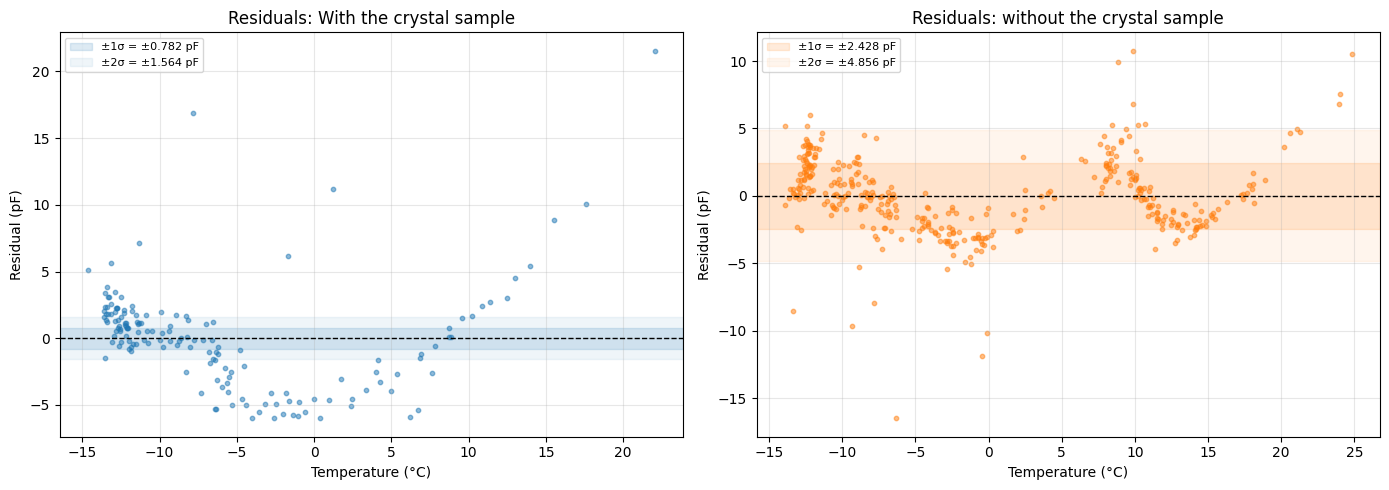

In [338]:
# Residual plots with standard error bands (using independent noise sigma per setup)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_s['temperature_C'].values, residuals_s, s=10, alpha=0.5, color='tab:blue')
ax1.axhline(0, color='k', linewidth=1, linestyle='--')
ax1.axhspan(-sigma_s_noise, sigma_s_noise, alpha=0.15, color='tab:blue', label=f'±1σ = ±{sigma_s_noise:.3f} pF')
ax1.axhspan(-2*sigma_s_noise, 2*sigma_s_noise, alpha=0.07, color='tab:blue', label=f'±2σ = ±{2*sigma_s_noise:.3f} pF')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Residual (pF)')
ax1.set_title('Residuals: With the crystal sample')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.scatter(df_n['temperature_C'].values, residuals_n, s=10, alpha=0.5, color='tab:orange')
ax2.axhline(0, color='k', linewidth=1, linestyle='--')
ax2.axhspan(-sigma_n_noise, sigma_n_noise, alpha=0.15, color='tab:orange', label=f'±1σ = ±{sigma_n_noise:.3f} pF')
ax2.axhspan(-2*sigma_n_noise, 2*sigma_n_noise, alpha=0.07, color='tab:orange', label=f'±2σ = ±{2*sigma_n_noise:.3f} pF')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Residual (pF)')
ax2.set_title('Residuals: without the crystal sample')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [339]:
side = 0.05  # m (5 cm)
delta_side = 0.1e-3  # m (0.1 mm)
A = side**2  # m^2
delta_A = 2 * side * delta_side  # error propagation for A = side^2

L0 = 0.18e-2  # m, with uncertainty of 0.01mm
delta_L0 = 0.01e-3  # m

air_permittivity = 8.854e-12  # F/m

C0 = 95.86e-12  # F (95.86084036834542 ± 0.059086364277937876) pF
delta_C0 = 0.059e-12  # F

# alpha = eps0 * A / (L0 * C0^2) * (m_s - m_n)
D0 = (air_permittivity * A) / C0
K = D0 / (L0 * C0)

m_s_F = m_s * 1e-12  # Convert pF/°C to F/°C
m_n_F = m_n * 1e-12
se_s_F = se_s * 1e-12
se_n_F = se_n * 1e-12

alpha = K * (m_s_F - m_n_F)

# Full error propagation (relative errors added in quadrature)
rel_A = delta_A / A
rel_L0 = delta_L0 / L0
rel_C0 = 2 * delta_C0 / C0  # factor of 2 because C0 appears squared
rel_m = np.sqrt(se_s_F**2 + se_n_F**2) / abs(m_s_F - m_n_F)

rel_alpha = np.sqrt(rel_A**2 + rel_L0**2 + rel_C0**2 + rel_m**2)
delta_alpha = abs(alpha) * rel_alpha

print("=== Error budget ===")
print(f"  δA/A         = {rel_A:.4e}  ({rel_A/rel_alpha*100:.1f}% of total)")
print(f"  δL0/L0       = {rel_L0:.4e}  ({rel_L0/rel_alpha*100:.1f}% of total)")
print(f"  2·δC0/C0     = {rel_C0:.4e}  ({rel_C0/rel_alpha*100:.1f}% of total)")
print(f"  δm/(ms-mn)   = {rel_m:.4e}  ({rel_m/rel_alpha*100:.1f}% of total)")
print(f"  δα/α (total) = {rel_alpha:.4e}")
print()
print(f"Thermal expansion coefficient: α = ({alpha * 1e5:.4f} ± {delta_alpha * 1e5:.4f}) x 10⁻⁵ /K")

=== Error budget ===
  δA/A         = 4.0000e-03  (1.0% of total)
  δL0/L0       = 5.5556e-03  (1.3% of total)
  2·δC0/C0     = 1.2310e-03  (0.3% of total)
  δm/(ms-mn)   = 4.1259e-01  (100.0% of total)
  δα/α (total) = 4.1265e-01

Thermal expansion coefficient: α = (13.6297 ± 5.6242) x 10⁻⁵ /K


In [340]:
# Comparison with literature values (Harvard)
# α1 = 6.41e-5 /K, α2 = 4.52e-5 /K, α3 = -4.32e-6 /K
lit_values = {
    'α₁': 6.41e-5,
    'α₂': 4.52e-5,
    'α₃': -4.32e-6,
}

print("=== Comparison with literature values ===")
print(f"  Our result: α = ({alpha * 1e5:.4f} ± {delta_alpha * 1e5:.4f}) x 10⁻⁵ /K")
print()
for name, alpha_lit in lit_values.items():
    n_sigma = abs(alpha - alpha_lit) / delta_alpha
    pct_err = abs(alpha - alpha_lit) / abs(alpha_lit) * 100
    print(f"  {name} = {alpha_lit:.2e} /K:  {n_sigma:.2f}σ away,  {pct_err:.1f}% error")

=== Comparison with literature values ===
  Our result: α = (13.6297 ± 5.6242) x 10⁻⁵ /K

  α₁ = 6.41e-05 /K:  1.28σ away,  112.6% error
  α₂ = 4.52e-05 /K:  1.62σ away,  201.5% error
  α₃ = -4.32e-06 /K:  2.50σ away,  3255.0% error
